In [1]:
# @title Running in Colab

from IPython.display import HTML, Javascript, display

display(
    HTML(
        """<a href="https://colab.research.google.com/github/evan-lloyd/mechinterp-experiments/blob/main/tiny_stories_sae/feature_interaction_demo.ipynb" target="_blank" id="colab-button">
            Run this notebook in Google Colab
        </a>"""
    )
)
display(
    Javascript("""
        setTimeout(() => {
            if(typeof google.colab != "undefined") {
                document.querySelector("#colab-button").remove()
            }
        }, 0);
        """)
)

<IPython.core.display.Javascript object>

# Initialize notebook environment

In [2]:
import os

# If we're running in Colab, we need to clone the non-notebook source from git.
if os.getenv("COLAB_RELEASE_TAG") and not os.path.isdir(
    "/content/mechinterp-experiments"
):
    ip = get_ipython()  #  pyright: ignore[reportUndefinedVariable]
    ip.run_cell_magic(
        "bash",
        "",
        """
    git clone --filter=blob:none --no-checkout https://github.com/evan-lloyd/mechinterp-experiments.git
    cd mechinterp-experiments
    git sparse-checkout init --no-cone
    echo "/tiny_stories_sae" > .git/info/sparse-checkout
    git checkout
  """,
    )
    ip.run_line_magic("cd", "mechinterp-experiments/tiny_stories_sae")
else:
    print("Already cloned source, or not running in Colab.")

# Nice for dev, but not needed for Colab.
try:
    # This uses a library called jurigged to hot-reload code when it is changed.
    # For reasons I've never been able to figure out, the IPython %autoreload magic
    # completely fails to work with the kind of structure I use in this notebook.
    import tiny_stories_sae._autoreload
except Exception:
    pass

Already cloned source, or not running in Colab.


In [3]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda"
    TRAINING_BATCH_SIZE = 16
    E2E_BATCH_SIZE = 4
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps"
    TRAINING_BATCH_SIZE = 8
    E2E_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 8
    E2E_BATCH_SIZE = 2

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
training_dataset = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
validation_dataset = load_dataset(
    "roneneldan/TinyStories", split="validation", streaming=True
)
model = AutoModelForCausalLM.from_pretrained("roneneldan/TinyStories-33M").to(
    TRAINING_DEVICE
)

print(model)

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-3): 4 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_feat

In [163]:
# Caches model activations to these directories; modify if necessary, or set to None to disable.
# These take up ~16GB and ~1.5GB respectively, but will save a fair bit of time when running
# the notebook, since they can be re-used across all methods we're comparing.
# TRAINING_CACHE_DIR = None
# VALIDATION_CACHE_DIR = None
TRAINING_CACHE_DIR = ".training_cache"
VALIDATION_CACHE_DIR = ".validation_cache"
NUM_TRAINING_TOKENS = int(1e6)
EVAL_INTERVAL = int(1e4)
NUM_VALIDATION_TOKENS = int(1e5)
D_MODEL = model.config.hidden_size
D_SAE = D_MODEL * 4
TOPK = 100
TOKENIZER_BATCH_SIZE = 128

# Train SAEs

In [5]:
from tiny_stories_sae.sae import SAE
from tiny_stories_sae.training import TrainingConfig, TrainingMethod, train
from itertools import product

def SAE_SPECS():
    return product(TrainingMethod, (False, True))

saes = {
    (method, use_interaction): {
        layer: SAE(
            D_MODEL,
            D_SAE,
            device=model.device,
            kind="topk",
            topk=100,
            use_interaction=use_interaction,
        )
        for layer in range(model.config.num_layers)
    }
    for method, use_interaction in SAE_SPECS()
    # We will clone these from the corresponding pre-fine-tuned method to save time
    if method not in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
}


def linear_decay(frac_trained: float):
    return 1.0 - frac_trained


training_config = {
    (method, use_interaction): TrainingConfig(
        tokenizer_batch_size=TOKENIZER_BATCH_SIZE,
        training_batch_size=TRAINING_BATCH_SIZE,
        e2e_batch_size=E2E_BATCH_SIZE,
        num_train_tokens=NUM_TRAINING_TOKENS,
        eval_interval=EVAL_INTERVAL,
        train_layers=list(range(model.config.num_layers)),
        lr=1e-3,
        interaction_lr=1e-3,
        finetune_lr_schedule=linear_decay,  # per Karvonen (2025)
        use_downstream_saes=method
        in (TrainingMethod.next_layer, TrainingMethod.next_layer_finetuned),
        downstream_reconstruction_weight=1.0
        if method in (TrainingMethod.next_layer, TrainingMethod.next_layer_finetuned)
        else 0.0,
        reconstruction_weight=1.0,
        balance_reconstruction_losses=method
        in (TrainingMethod.next_layer, TrainingMethod.next_layer_finetuned),
        method=method,
        finetune_fraction=0.10
        if method in (TrainingMethod.finetuned, TrainingMethod.next_layer_finetuned)
        else None,
    )
    for method, use_interaction in SAE_SPECS()
}

training_results = {}

In [164]:
from tiny_stories_sae.ops import clone_sae

training_config[(TrainingMethod.standard, True)].train_layers = [3]
training_config[(TrainingMethod.standard, True)].interaction_lr = 1e-3
training_config[(TrainingMethod.standard, True)].num_train_tokens = NUM_TRAINING_TOKENS
saes[(TrainingMethod.standard, True)][3].use_interaction = True
saes[(TrainingMethod.standard, True)][3].topk = TOPK
saes[(TrainingMethod.standard, True)][3].d_sae = D_SAE

results = train(
    model,
    tokenizer,
    saes[(TrainingMethod.standard, True)],
    training_dataset,
    training_config[(TrainingMethod.standard, True)],
    cache_dir=TRAINING_CACHE_DIR,
    reinit_weights=True,
)
training_results[(TrainingMethod.standard, True)][3] = results[3]

Layer 3

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [165]:
saes[(TrainingMethod.standard, True)][3].interaction.min()

tensor(-0.1359, device='mps:0', grad_fn=<MinBackward1>)

In [166]:
training_config[(TrainingMethod.standard, False)].train_layers = [3]
training_config[(TrainingMethod.standard, False)].num_train_tokens = NUM_TRAINING_TOKENS
saes[(TrainingMethod.standard, False)][3].topk = TOPK
saes[(TrainingMethod.standard, False)][3].d_sae = D_SAE

results = train(
    model,
    tokenizer,
    saes[(TrainingMethod.standard, False)],
    training_dataset,
    training_config[(TrainingMethod.standard, False)],
    cache_dir=TRAINING_CACHE_DIR,
    reinit_weights=True,    
)
training_results[(TrainingMethod.standard, False)][3] = results[3]

Layer 3

  0%|          | 0/1000000 [00:00<?, ?it/s]

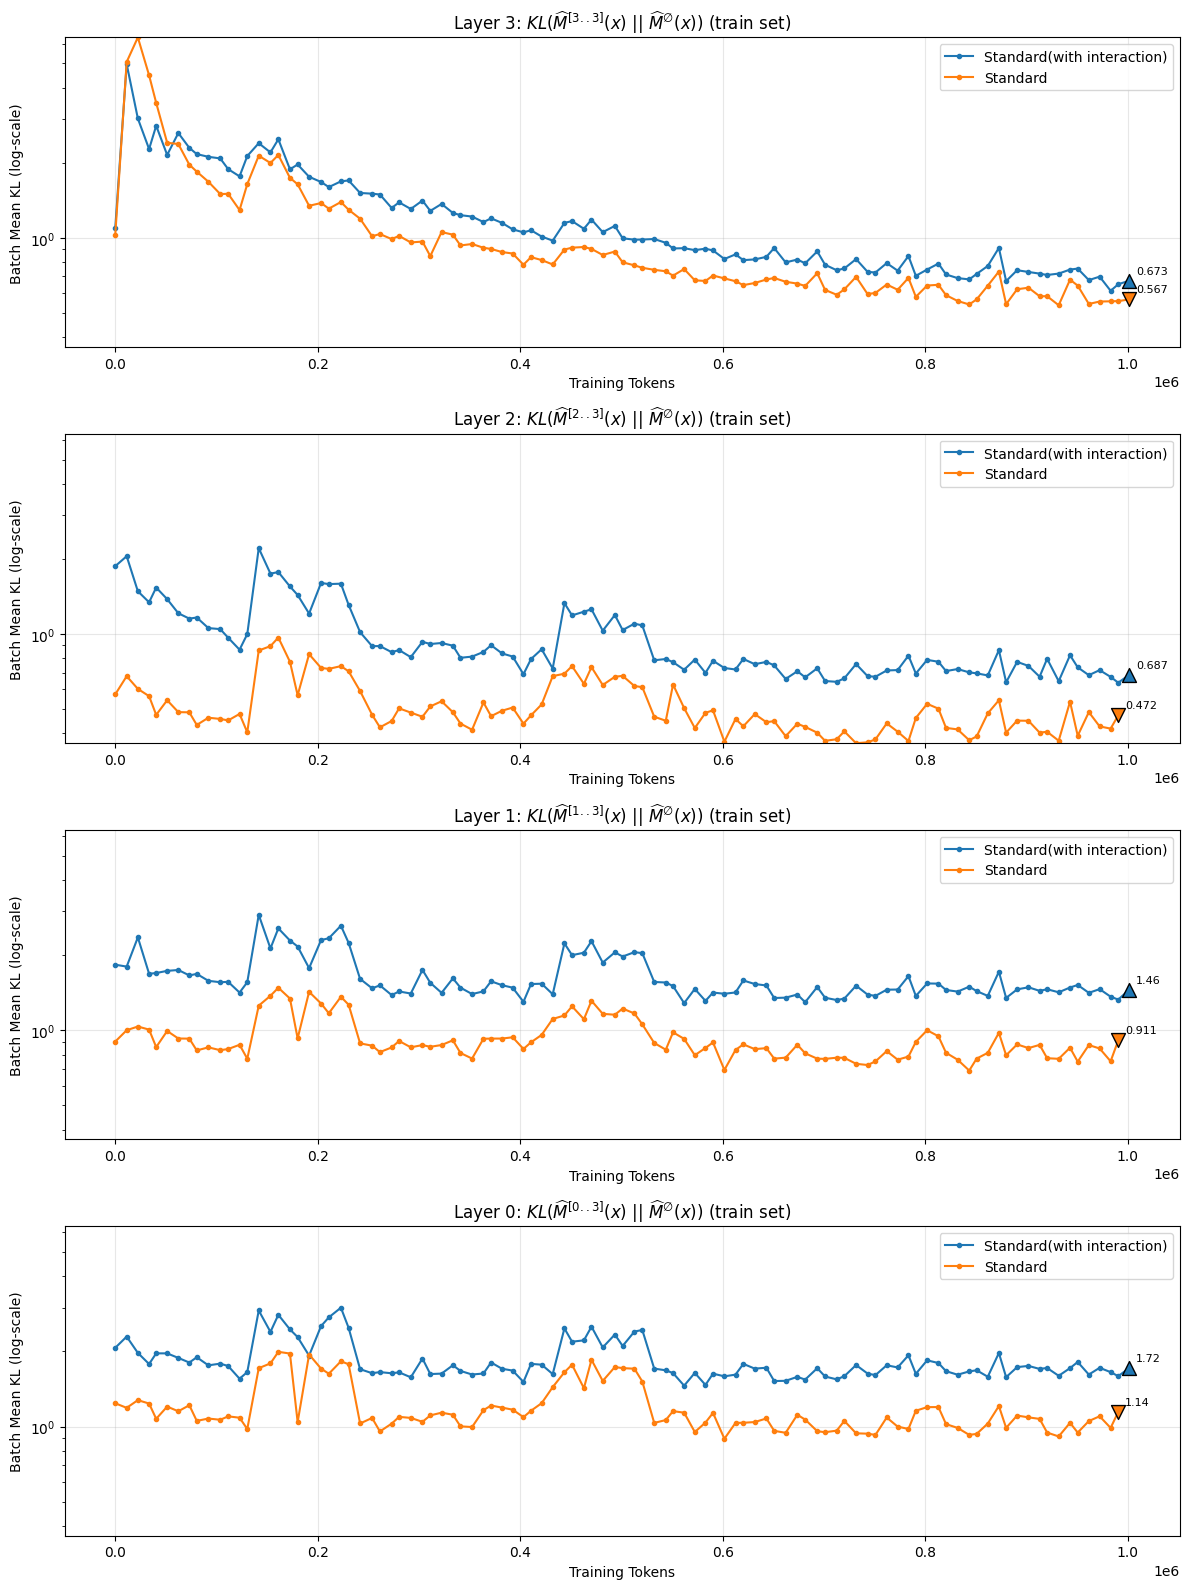

In [ ]:
from tiny_stories_sae.ops import current_plot_to_svg
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    model.config.num_layers, 1, figsize=(12, 4 * model.config.num_layers)
)

# Collect all KL values to determine consistent y-axis limits
all_kl_values = []
for layer in range(model.config.num_layers):
    for spec in training_results:
        data = training_results[spec][layer]["rep_kl"]
        if data:
            _, kl_values = zip(*data)
            all_kl_values.extend(kl_values)

# Calculate y-axis limits
if all_kl_values:
    y_min, y_max = min(all_kl_values), max(all_kl_values)
else:
    y_min, y_max = 1e-3, 1e0  # Default range if no data

for i, layer in enumerate(range(model.config.num_layers - 1, -1, -1)):
    ax = axes[i]

    # Collect final values for each method to find min/max
    final_values = {}
    line_colors = {}
    for spec in training_results:
        data = training_results[spec][layer]["rep_kl"]
        if data:
            tokens, kl_values = zip(*data)
            # Skip plotting some steps to reduce clutter
            line = ax.plot(
                tokens,
                kl_values,
                label=f"{spec[0].value}{'(with interaction)' if spec[1] else ''}",
                marker="o",
                markersize=3,
            )
            line_colors[spec] = line[0].get_color()

            if tokens and kl_values:
                final_values[spec] = (tokens[-1], kl_values[-1])

    # Find methods with highest and lowest final values
    if final_values:
        min_method = min(final_values.keys(), key=lambda m: final_values[m][1])
        max_method = max(final_values.keys(), key=lambda m: final_values[m][1])

        # Add indicators for min (down triangle) and max (up triangle)
        for spec in [min_method, max_method]:
            final_token, final_kl = final_values[spec]
            marker = "^" if spec == max_method else "v"
            ax.scatter(
                final_token,
                final_kl,
                s=100,
                marker=marker,
                color=line_colors[spec],
                edgecolors="black",
                linewidth=1,
                zorder=10,
            )
            ax.annotate(
                f"{final_kl:.3}",
                xy=(final_token, final_kl),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
                ha="left",
            )

    # Add vertical line at finetuning start
    # ax.axvline(x=9e6, color="gray", linestyle="--", alpha=0.7)

    ax.set_xlabel("Training Tokens")
    ax.set_ylabel("Batch Mean KL (log-scale)")
    ax.set_yscale("log")
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f"Layer {layer}: $KL(\\widehat{{M}}^{{[{layer}..3]}}(x)\\ ||\\ \\widehat{{M}}^{{\\emptyset}}(x))$ (train set)"
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

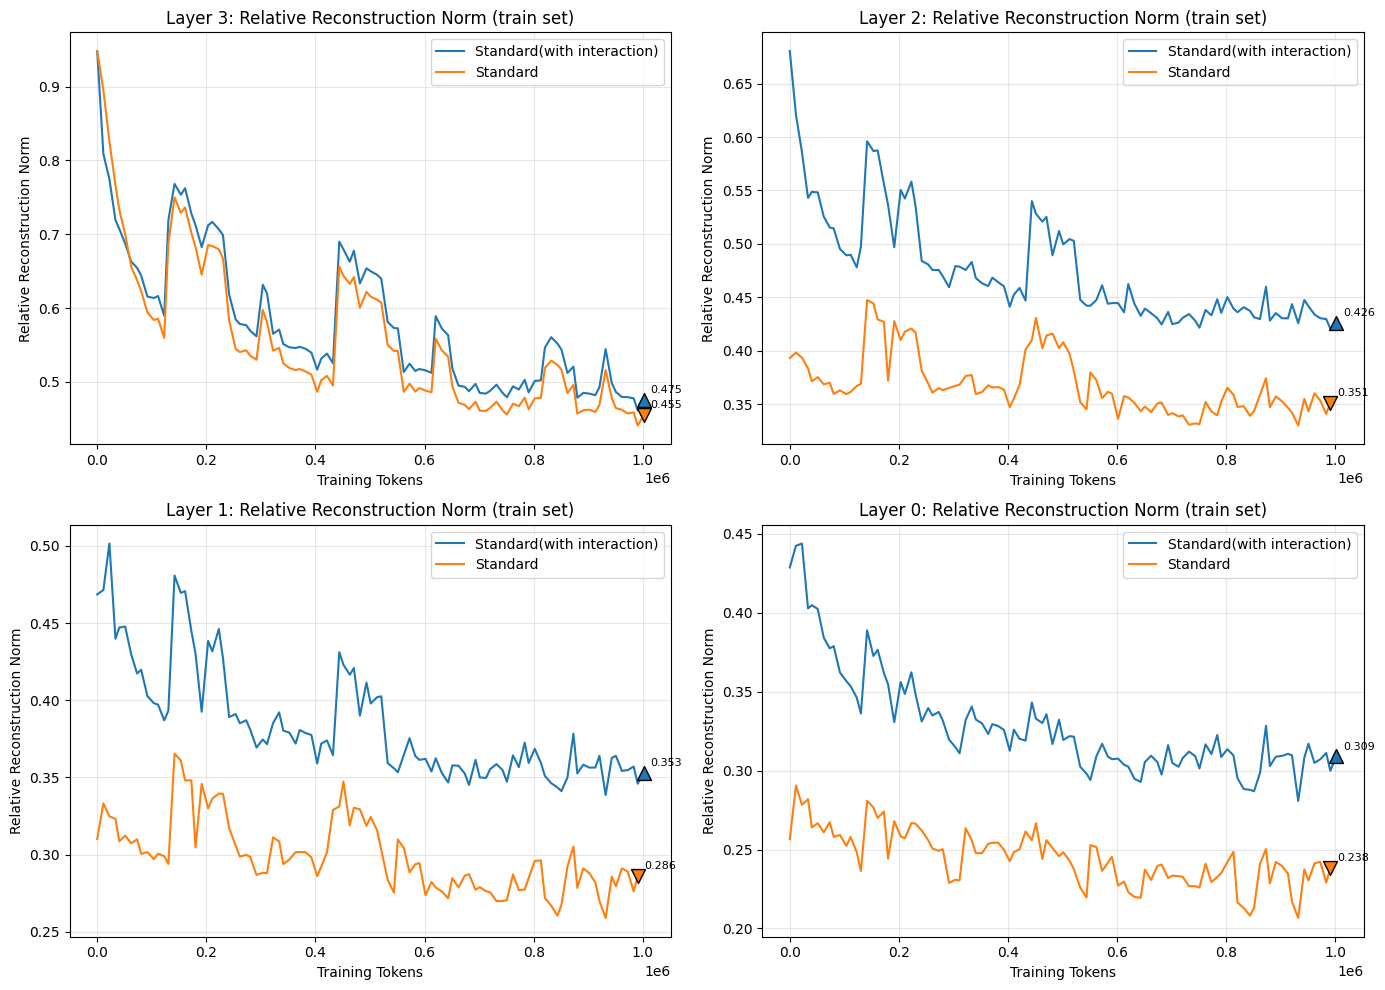

In [168]:
# Plot relative reconstruction norm (RCN) for each layer
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, layer in enumerate(range(model.config.num_layers -1, -1, -1)):
    ax = axes[idx]

    # Collect final values for min/max annotation
    final_values = {}

    for spec in training_results:
        if layer in training_results[spec] and "rcn" in training_results[spec][layer]:
            data = training_results[spec][layer]["rcn"]
            tokens = [item[0] for item in data]
            rcn_values = [item[1] for item in data]

            ax.plot(
                tokens,
                rcn_values,
                label=f"{spec[0].value}{'(with interaction)' if spec[1] else ''}",
                color=line_colors[spec],
            )

            if tokens and rcn_values:
                final_values[spec] = (tokens[-1], rcn_values[-1])

    # Find methods with highest and lowest final values
    if final_values:
        min_method = min(final_values.keys(), key=lambda m: final_values[m][1])
        max_method = max(final_values.keys(), key=lambda m: final_values[m][1])

        # Add indicators for min (down triangle) and max (up triangle)
        for spec in [min_method, max_method]:
            final_token, final_rcn = final_values[spec]
            marker = "^" if spec == max_method else "v"
            ax.scatter(
                final_token,
                final_rcn,
                s=100,
                marker=marker,
                color=line_colors[spec],
                edgecolors="black",
                linewidth=1,
                zorder=10,
            )
            ax.annotate(
                f"{final_rcn:.3}",
                xy=(final_token, final_rcn),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
                ha="left",
            )

    ax.set_xlabel("Training Tokens")
    ax.set_ylabel("Relative Reconstruction Norm")
    ax.set_title(f"Layer {layer}: Relative Reconstruction Norm (train set)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

In [169]:
from tiny_stories_sae.validation import validate_saes

if "validation_evals" not in globals():
    validation_evals = {}
    replacement_evals = {}
    position_ids = {}
for spec in training_results.keys():
    # if not spec[1]:
    #     continue
    validation_evals[spec], replacement_evals[spec], position_ids[spec] = (
        validate_saes(
            model,
            tokenizer,
            saes[spec],
            validation_dataset,
            num_tokens=NUM_VALIDATION_TOKENS,
            tokenizer_batch_size=training_config[spec].tokenizer_batch_size,
            inference_batch_size=training_config[spec].training_batch_size,
            cache_dir=VALIDATION_CACHE_DIR,
        )
    )

Running SAE evals:   0%|          | 0/100000 [00:00<?, ?it/s]

Running SAE evals:   0%|          | 0/100000 [00:00<?, ?it/s]

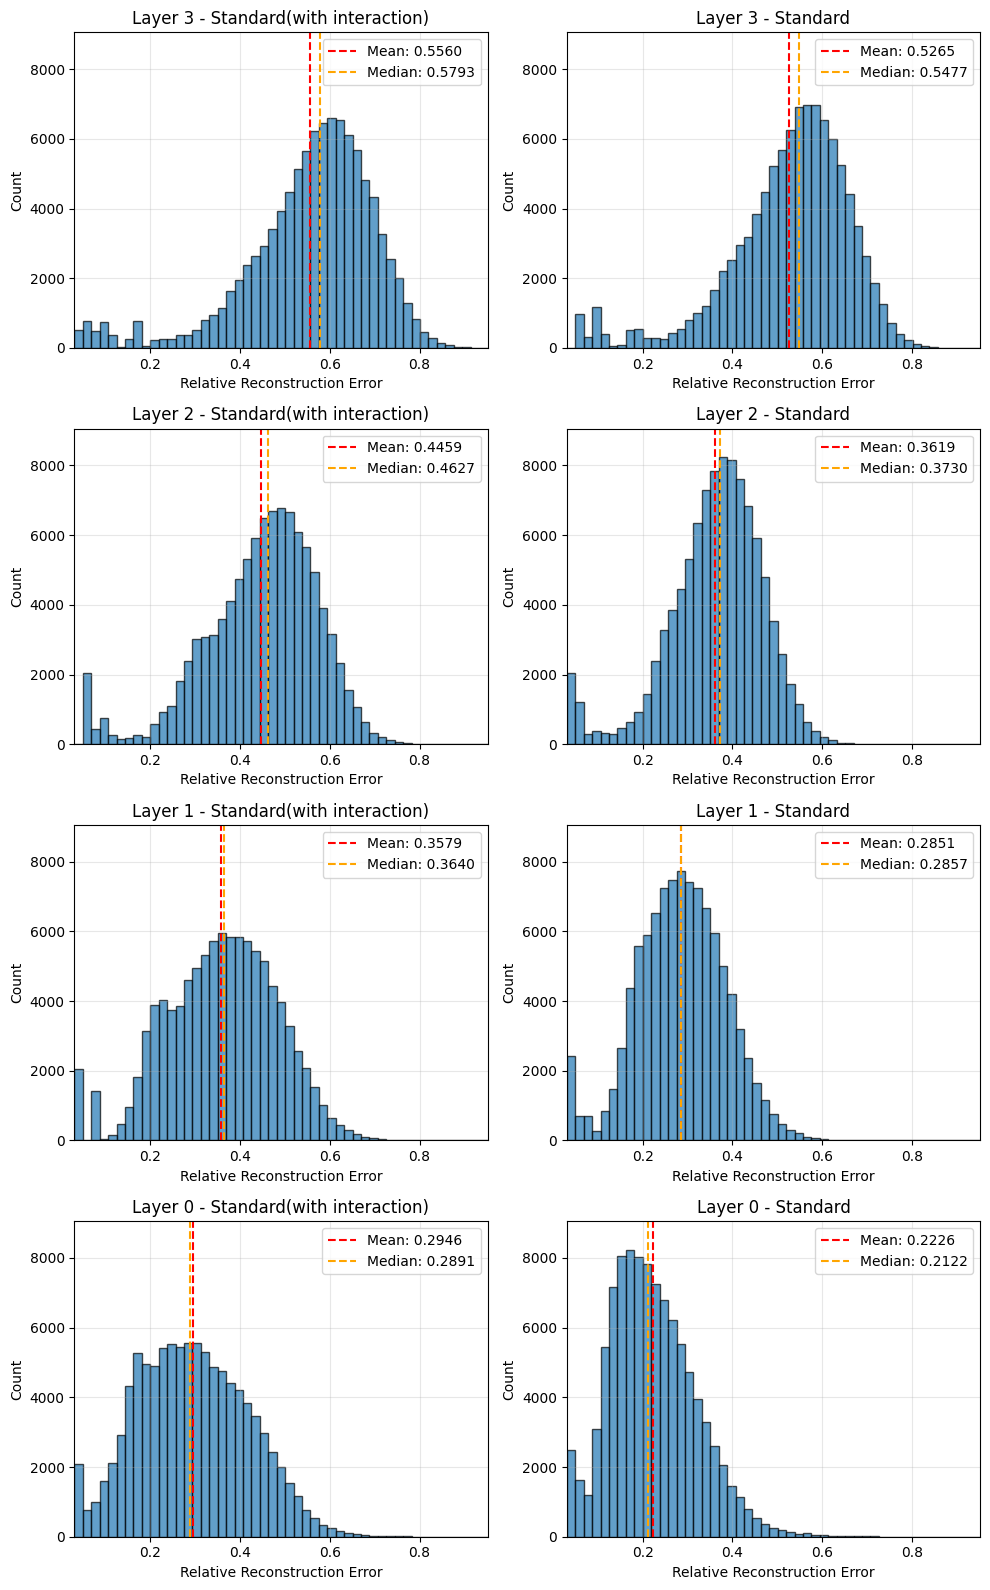

In [170]:
import numpy as np

ncols = len(validation_evals)
nrows = model.config.num_layers

# Plot reconstruction error histograms
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))

# Collect all rcn values to determine global range
all_rcn_values = []
for spec in validation_evals:
    for layer in validation_evals[spec]:
        rcn_values = validation_evals[spec][layer]["rcn"]
        all_rcn_values.extend(rcn_values)

# Create consistent bins for all histograms
global_min = min(all_rcn_values)
global_max = max(all_rcn_values)
bins = np.linspace(global_min, global_max, 50)

# Find maximum frequency for consistent y-axis scaling
max_frequency = 0
for spec in validation_evals:
    for layer in validation_evals[spec]:
        rcn_values = validation_evals[spec][layer]["rcn"]
        counts, _ = np.histogram(rcn_values, bins=bins)
        max_frequency = max(max_frequency, max(counts))

# Plot histograms for each layer and method
for layer in range(model.config.num_layers):
    for i, spec in enumerate(validation_evals):
        # Reverse layer order: highest layer numbers on top
        plot_row = model.config.num_layers - 1 - layer
        row = plot_row
        col = i
        ax = axes[row][col]

        rcn_values = validation_evals[spec][layer]["rcn"]

        # Create histogram with consistent bins
        ax.hist(rcn_values, bins=bins, alpha=0.7, edgecolor="black")
        ax.set_xlim(global_min, global_max)
        ax.set_ylim(0, max_frequency * 1.1)
        ax.set_xlabel("Relative Reconstruction Error")
        ax.set_ylabel("Count")
        ax.set_title(
            f"Layer {layer} - {spec[0].value}{'(with interaction)' if spec[1] else ''}"
        )
        ax.grid(True, alpha=0.3)

        # Add statistics
        mean_rcn = np.mean(rcn_values)
        median_rcn = np.median(rcn_values)

        ax.axvline(mean_rcn, color="red", linestyle="--", label=f"Mean: {mean_rcn:.4f}")
        ax.axvline(
            median_rcn,
            color="orange",
            linestyle="--",
            label=f"Median: {median_rcn:.4f}",
        )

        ax.legend()

# Hide any unused subplots
total_plots = model.config.num_layers * len(TrainingMethod)
for i in range(total_plots, nrows * ncols):
    row = i // ncols
    col = i % ncols
    ax = axes[row][col]
    ax.set_visible(False)

plt.tight_layout()


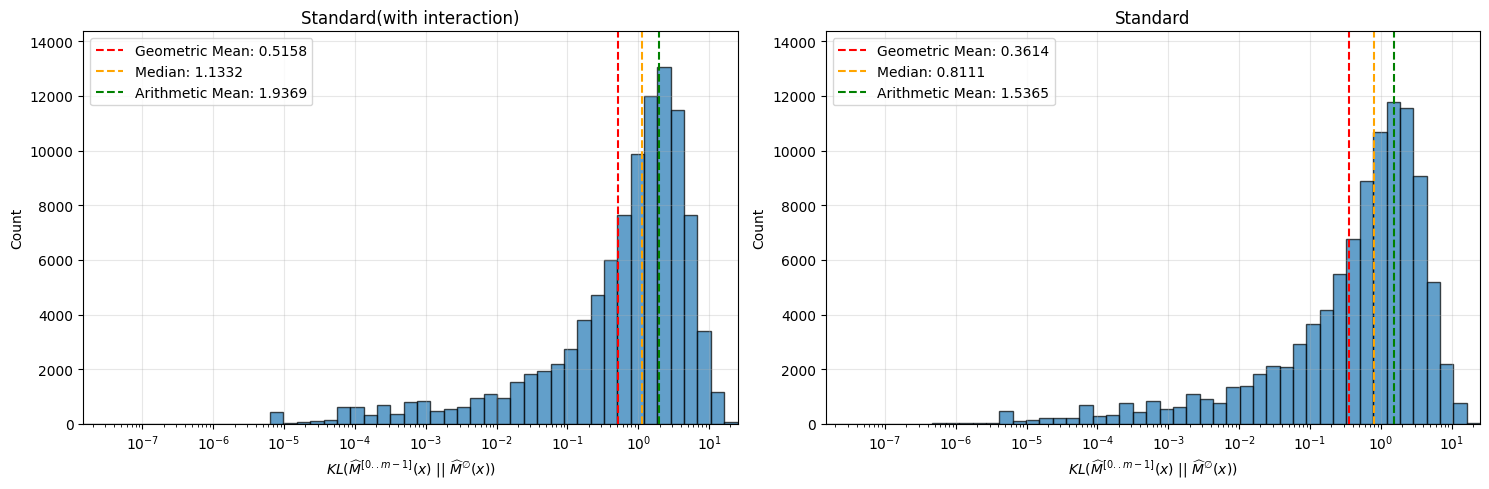

In [171]:
import matplotlib.pyplot as plt
import numpy as np
from tiny_stories_sae.ops import current_plot_to_svg

# Plot histograms of KL divergence for each method
num_specs = len(list(replacement_evals.keys()))
ncols = 2
nrows = (num_specs + ncols - 1) // ncols  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))

# Handle case where we have only one row
if nrows == 1:
    axes = axes.reshape(1, -1)
# Handle case where we have only one method
if num_specs == 1:
    axes = axes.reshape(-1)

# Calculate global min/max for consistent bins across all methods
all_kl_values = []
for spec in replacement_evals.keys():
    kl_values = replacement_evals[spec]["kl"]
    all_kl_values.extend(kl_values[kl_values > 0])

global_min = np.min(all_kl_values)
global_max = np.max(all_kl_values)
log_bins = np.logspace(np.log10(global_min), np.log10(global_max), 50)

# Calculate global y-axis limits
max_frequency = 0
for spec in replacement_evals.keys():
    kl_values = replacement_evals[spec]["kl"]
    counts, _ = np.histogram(kl_values, bins=log_bins)
    max_frequency = max(max_frequency, np.max(counts))

for i, spec in enumerate(replacement_evals.keys()):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col]
    
    kl_values = replacement_evals[spec]["kl"]

    # Create histogram with consistent bins
    ax.hist(kl_values, bins=log_bins, alpha=0.7, edgecolor="black")
    ax.set_xscale("log")
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(0, max_frequency * 1.1)
    ax.set_xlabel(r"$KL(\widehat{M}^{[0..m-1]}(x)\ ||\ \widehat{M}^{\emptyset}(x))$")
    ax.set_ylabel("Count")
    ax.set_title(f"{spec[0].value}{'(with interaction)' if spec[1] else ''}")
    ax.grid(True, alpha=0.3)

    # Compute log-normal distribution statistics
    log_kl_values = np.log(kl_values[kl_values > 0])
    log_mean = np.mean(log_kl_values)
    log_std = np.std(log_kl_values)
    
    # Geometric mean and geometric standard deviation for log-normal distribution
    geometric_mean = np.exp(log_mean)
    geometric_std = np.exp(log_std)
    
    # Median is the same as geometric mean for log-normal
    median_kl = np.median(kl_values)
    
    # Arithmetic mean
    mean_kl = np.mean(kl_values)
    
    ax.axvline(geometric_mean, color="red", linestyle="--", label=f"Geometric Mean: {geometric_mean:.4f}")
    ax.axvline(
        median_kl, color="orange", linestyle="--", label=f"Median: {median_kl:.4f}"
    )
    ax.axvline(
        mean_kl, color="green", linestyle="--", label=f"Arithmetic Mean: {mean_kl:.4f}"
    )
    
    ax.legend()

# Hide any unused subplots
for i in range(num_specs, nrows * ncols):
    row = i // ncols
    col = i % ncols
    ax = axes[row, col] if nrows > 1 else axes[col]
    ax.set_visible(False)

plt.tight_layout()